# PHASE 3: Dataset Split — full-dataset stratified 70/15/15 (no reserved split)

In [1]:
import warnings
from transformers import logging as hf_logging

# Set transformers to error level (suppresses info/warnings)
hf_logging.set_verbosity_error()

# Suppress specific deprecation warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*gradient_checkpointing.*')
warnings.filterwarnings('ignore', message='.*Some weights of.*were not initialized.*')

In [1]:
# Imports
import os
import csv
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print('All imports successful')

All imports successful


In [2]:
# Configuration
OCR_BASE_DIR = os.path.join(os.getcwd(), 'ocr_images')
LANGS = ['EN', 'MY', 'CN']
LANG_MAP = {'EN': 0, 'MY': 1, 'CN': 2}
LANG_NAMES = ['English', 'Malay', 'Mandarin']

# Model config
MODEL_NAME = 'distilbert-base-multilingual-cased'
MAX_LENGTH = 128  # max token length


print(f'OCR base dir: {OCR_BASE_DIR}')
print(f'Model: {MODEL_NAME}')


OCR base dir: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images
Model: distilbert-base-multilingual-cased


In [3]:
# Load OCR dataset from labels.csv files
texts = []
labels = []

for lang in LANGS:
    lang_dir = os.path.join(OCR_BASE_DIR, lang)
    labels_file = os.path.join(lang_dir, 'labels.csv')
    
    if not os.path.exists(labels_file):
        print(f" {lang}: labels.csv not found at {labels_file}")
        continue
    
    count = 0
    with open(labels_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if 'text' in row and row['text'].strip():
                texts.append(row['text'].strip())
                labels.append(LANG_MAP[lang])
                count += 1
    
    print(f" {lang}: {count} text samples loaded")

print(f"\n Total samples: {len(texts)}")
if len(texts) == 0:
    print(" No OCR data found! Generate OCR images first.")

 EN: 5000 text samples loaded
 MY: 5000 text samples loaded
 CN: 5000 text samples loaded

 Total samples: 15000


In [4]:
# Full-dataset stratified 70/15/15 split (use 100% of OCR texts)
texts_array = np.array(texts)
labels_array = np.array(labels)

# Split: train 70% / val 15% / test 15% of the FULL dataset
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts_array, labels_array, test_size=0.30, random_state=42, stratify=labels_array
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f" Full-dataset stratified split (70/15/15):")
print(f"   Total samples: {len(texts_array)}")
print(f"   Train: {len(train_texts)} samples ({100*len(train_texts)/len(texts_array):.1f}% of total)")
print(f"   Val:   {len(val_texts)} samples ({100*len(val_texts)/len(texts_array):.1f}% of total)")
print(f"   Test:  {len(test_texts)} samples ({100*len(test_texts)/len(texts_array):.1f}% of total)")

# Verify stratification across languages
print(f"\n Label distribution (full dataset splits):")
for lang_id, lang_name in enumerate(LANG_NAMES):
    train_count = np.sum(train_labels == lang_id)
    val_count = np.sum(val_labels == lang_id)
    test_count = np.sum(test_labels == lang_id)
    print(f"   {lang_name}: Train {train_count} | Val {val_count} | Test {test_count}")

 Full-dataset stratified split (70/15/15):
   Total samples: 15000
   Train: 10500 samples (70.0% of total)
   Val:   2250 samples (15.0% of total)
   Test:  2250 samples (15.0% of total)

 Label distribution (full dataset splits):
   English: Train 3500 | Val 750 | Test 750
   Malay: Train 3500 | Val 750 | Test 750
   Mandarin: Train 3500 | Val 750 | Test 750


In [5]:
# GPU Check
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | CUDA: {torch.version.cuda}")
else:
    print('GPU not available - wav2vec2 training will be slow')

globals()['device'] = device

Using device: cuda
GPU: NVIDIA GeForce GTX 1650 | CUDA: 11.8


In [6]:
# Load tokenizer and model
print('Loading tokenizer and model...')
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
model = DistilBertForSequenceClassification.from_pretrained(    MODEL_NAME,
    num_labels=len(LANG_MAP)).to(device)

# Count trainable params
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded")
print(f"   Trainable params: {trainable_params:,}")
print(f"   Device: {device}")

Loading tokenizer and model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded
   Trainable params: 135,326,979
   Device: cuda


In [7]:
# Custom Dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets (loaders will be created by hyperparameter search in Cell 10)
train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)
test_dataset = TextDataset(test_texts, test_labels, tokenizer, MAX_LENGTH)

print(f" Datasets created:")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Val:   {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")

 Datasets created:
   Train: 10500 samples
   Val:   2250 samples
   Test:  2250 samples


# Hyperparameter Search

**What varies in Random Search:**
- `learning_rate`: Random choice from [0.000005, 0.00001, 0.00002, 0.00003, 0.00005]
- `batch_size`: Random choice from [8, 16, 24]
- `num_epochs`: Random choice from [2, 3, 4, 5]
- `weight_decay`: Random choice from [0.0, 0.01, 0.05]

**What stays fixed:**
- `MODEL_NAME` = 'distilbert-base-multilingual-cased'
- `MAX_LENGTH` = 128 tokens
- Dataset splits (train/val/test)
- Early stopping patience = 3 epochs

**How it works:**
1. Runs 10 trials (N_TRIALS = 10)
2. Each trial: randomly samples ONE combination from the search space
3. Trains that configuration for up to 4 epochs
4. **Early stopping**: If validation accuracy doesn't improve for 3 consecutive epochs, training stops
5. Saves best validation accuracy and model weights for that trial
6. After all trials, selects the best overall configuration

**Early Stopping Behavior:**
- Trial will stop BEFORE reaching `num_epochs` if no improvement
- Example: If `num_epochs=4` but val acc stops improving after epoch 2, training stops at epoch 2
- This saves time and prevents overfitting

In [8]:
# Hyperparameter Search Setup: Imports and Configuration
import random
import copy
import time
import matplotlib.pyplot as plt
import pandas as pd
from torch.optim import AdamW
from tqdm.notebook import tqdm
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

# Search config
SEARCH_MODE = 'random'  # 'random' or 'bayes'
N_TRIALS = 10            # number of random configurations to try
PATIENCE = 3            # early stopping patience (epochs without val improvement)

search_space = {
    'learning_rate': [5e-6, 1e-5, 2e-5, 3e-5, 5e-5],
    'batch_size': [8, 16, 24],
    'num_epochs': [2, 3, 4, 5],
    'weight_decay': [0.0, 0.01, 0.05]
}

print(f'Search Mode: {SEARCH_MODE.upper()}')
print(f'Number of Trials: {N_TRIALS}')
print(f'Early Stopping Patience: {PATIENCE} epochs')
print(f'\nSearch Space:')
for param, values in search_space.items():
    print(f'  {param}: {values}')

Search Mode: RANDOM
Number of Trials: 10
Early Stopping Patience: 3 epochs

Search Space:
  learning_rate: [5e-06, 1e-05, 2e-05, 3e-05, 5e-05]
  batch_size: [8, 16, 24]
  num_epochs: [2, 3, 4, 5]
  weight_decay: [0.0, 0.01, 0.05]


In [9]:
# Helper Functions for Hyperparameter Search

def make_loaders(batch_size):
    """Create dataloaders with specified batch size"""
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
    )

def run_one(cfg):
    """Train one configuration with early stopping"""
    train_loader, val_loader = make_loaders(cfg['batch_size'])
    model_local = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LANG_MAP)
    ).to(device)
    optimizer = AdamW(model_local.parameters(), lr=cfg['learning_rate'], weight_decay=cfg['weight_decay'])
    best_val = 0.0
    best_state = None
    no_improve = 0
    
    for epoch in range(cfg['num_epochs']):
        # Training
        model_local.train()
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            optimizer.zero_grad()
            outputs = model_local(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            outputs.loss.backward()
            optimizer.step()
        
        # Validation
        model_local.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                logits = model_local(input_ids=input_ids, attention_mask=attention_mask).logits
                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = 100.0 * correct / total
        
        # Early stopping check
        if val_acc > best_val:
            best_val = val_acc
            best_state = copy.deepcopy(model_local.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        
        if no_improve >= PATIENCE:
            break  # Stop early if no improvement
    
    return best_val, best_state

def sample_cfg(trial=None):
    """Sample a random configuration from search space"""
    if SEARCH_MODE == 'bayes' and trial is not None:
        return {
            'learning_rate': trial.suggest_float('learning_rate', 5e-6, 5e-5, log=True),
            'batch_size': trial.suggest_categorical('batch_size', search_space['batch_size']),
            'num_epochs': trial.suggest_int('num_epochs', 2, 4),
            'weight_decay': trial.suggest_float('weight_decay', 0.0, 0.05)
        }
    return {
        'learning_rate': random.choice(search_space['learning_rate']),
        'batch_size': random.choice(search_space['batch_size']),
        'num_epochs': random.choice(search_space['num_epochs']),
        'weight_decay': random.choice(search_space['weight_decay'])
    }

print(' Helper functions defined successfully')

 Helper functions defined successfully


In [10]:
# Run Hyperparameter Search (Random or Bayesian)
results = []
best_overall = {'val_acc': -1}

if SEARCH_MODE == 'bayes':
    if not OPTUNA_AVAILABLE:
        print(' Optuna not installed; falling back to random search.')
        SEARCH_MODE = 'random'
    else:
        def objective(trial):
            cfg = sample_cfg(trial)
            cfg['trial'] = trial.number + 1
            start = time.time()
            val_acc, state = run_one(cfg)
            duration = time.time() - start
            results.append({**cfg, 'best_val_acc': val_acc, 'duration_sec': duration})
            if val_acc > best_overall.get('val_acc', -1):
                best_overall.update({'cfg': cfg, 'val_acc': val_acc, 'state': state})
                torch.save(state, 'distilbert_best_model.pth')
            return val_acc
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

if SEARCH_MODE == 'random':
    print(f'\nStarting Random Search ({N_TRIALS} trials with early stopping)...\n')
    for t in tqdm(range(1, N_TRIALS + 1), desc='Random Search Progress', unit='trial'):
        cfg = sample_cfg()
        cfg['trial'] = t
        start = time.time()
        val_acc, state = run_one(cfg)
        duration = time.time() - start
        results.append({**cfg, 'best_val_acc': val_acc, 'duration_sec': duration})
        if val_acc > best_overall.get('val_acc', -1):
            best_overall.update({'cfg': cfg, 'val_acc': val_acc, 'state': state})
            torch.save(state, 'distilbert_best_model.pth')
        tqdm.write(f"Trial {t}/{N_TRIALS}: lr={cfg['learning_rate']:.2e}, bs={cfg['batch_size']}, ep={cfg['num_epochs']}, wd={cfg['weight_decay']:.3f} -> Val {val_acc:.2f}%")

print(f'\n Search complete! Best validation accuracy: {best_overall["val_acc"]:.2f}%')


Starting Random Search (10 trials with early stopping)...



Random Search Progress:   0%|          | 0/10 [00:00<?, ?trial/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trial 1/10: lr=3.00e-05, bs=24, ep=4, wd=0.010 -> Val 99.69%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Trial 8/10: lr=5.00e-06, bs=8, ep=3, wd=0.050 -> Val 99.64%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trial 9/10: lr=5.00e-06, bs=24, ep=4, wd=0.010 -> Val 99.64%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trial 10/10: lr=1.00e-05, bs=24, ep=4, wd=0.050 -> Val 99.78%

 Search complete! Best validation accuracy: 99.78%


In [11]:
# Process Results and Display Top Trials
if len(results) == 0:
    print('No search results recorded.')
else:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    
    # Ensure integer types for batch_size, num_epochs, trial
    results_df['batch_size'] = results_df['batch_size'].astype(int)
    results_df['num_epochs'] = results_df['num_epochs'].astype(int)
    results_df['trial'] = results_df['trial'].astype(int)
    
    top5 = results_df.head(5)
    
    print('\n' + '='*70)
    print('DISTILBERT HYPERPARAMETER SEARCH RESULTS')
    print('='*70)
    print(f'\nSearch Mode: {SEARCH_MODE.upper()}')
    print(f'Total Trials: {N_TRIALS}')
    print(f'Early Stopping Patience: {PATIENCE} epochs')
    print('\nTop 5 Trials:')
    print(top5[['trial', 'learning_rate', 'batch_size', 'num_epochs', 'weight_decay', 'best_val_acc', 'duration_sec']].to_string(index=False))
    print('\n' + '='*70)
    
    # Save detailed results to CSV
    results_df.to_csv('distilbert_hyperparam_results.csv', index=False)
    print('\n Detailed results saved: distilbert_hyperparam_results.csv')


DISTILBERT HYPERPARAMETER SEARCH RESULTS

Search Mode: RANDOM
Total Trials: 10
Early Stopping Patience: 3 epochs

Top 5 Trials:
 trial  learning_rate  batch_size  num_epochs  weight_decay  best_val_acc  duration_sec
     2        0.00003           8           4          0.05     99.777778   2442.577237
    10        0.00001          24           4          0.05     99.777778   3524.418040
     4        0.00002          16           5          0.05     99.733333   1805.309765
     6        0.00002          16           4          0.00     99.733333   1811.157892
     1        0.00003          24           4          0.01     99.688889   1352.620181


 Detailed results saved: distilbert_hyperparam_results.csv


In [12]:
# GRID SEARCH: Run after random search
print("\n" + "="*70)
print("RUNNING GRID SEARCH (24 configurations)")
print("="*70)

from itertools import product

# Reduced grid covering representative values
grid_space = {
    'learning_rate': [5e-6, 2e-5, 5e-5],
    'batch_size': [8, 16],
    'num_epochs': [2, 3],
    'weight_decay': [0.0, 0.01],
}

keys = list(grid_space.keys())
grid_configs = [dict(zip(keys, vals)) for vals in product(*[grid_space[k] for k in keys])]
print(f'\nGrid configurations to evaluate: {len(grid_configs)}\n')

# Run grid search
grid_results = []
grid_best = {'val_acc': -1}

for i, cfg in enumerate(tqdm(range(len(grid_configs)), desc='Grid Search', unit='config')):
    cfg_grid = grid_configs[cfg].copy()
    cfg_grid['trial'] = i + 1
    start = time.time()
    val_acc, state = run_one(cfg_grid)
    duration = time.time() - start
    grid_results.append({**cfg_grid, 'best_val_acc': val_acc, 'duration_sec': duration})
    if val_acc > grid_best['val_acc']:
        grid_best.update({'cfg': cfg_grid, 'val_acc': val_acc, 'state': state})
        torch.save(state, 'distilbert_grid_best.pth')
    tqdm.write(f"Grid {i+1}/24: lr={cfg_grid['learning_rate']:.2e}, bs={cfg_grid['batch_size']}, ep={cfg_grid['num_epochs']}, wd={cfg_grid['weight_decay']:.3f} → Val {val_acc:.2f}%")

# Save grid results
grid_df = pd.DataFrame(grid_results).sort_values('best_val_acc', ascending=False)
grid_df.to_csv('distilbert_grid_results.csv', index=False)
print(f'\n✅ Grid search complete! Best validation accuracy: {grid_best["val_acc"]:.2f}%')
print(f'✅ Grid results saved: distilbert_grid_results.csv')



RUNNING GRID SEARCH (24 configurations)

Grid configurations to evaluate: 24



Grid Search:   0%|          | 0/24 [00:00<?, ?config/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Grid 1/24: lr=5.00e-06, bs=8, ep=2, wd=0.000 → Val 99.64%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Grid 22/24: lr=5.00e-05, bs=16, ep=2, wd=0.010 → Val 99.56%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Grid 23/24: lr=5.00e-05, bs=16, ep=3, wd=0.000 → Val 99.60%


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Grid 24/24: lr=5.00e-05, bs=16, ep=3, wd=0.010 → Val 99.56%

✅ Grid search complete! Best validation accuracy: 99.82%
✅ Grid results saved: distilbert_grid_results.csv


In [23]:
# COMPARISON: Random Search vs Grid Search
print("\n" + "="*70)
print("HYPERPARAMETER SEARCH COMPARISON: RANDOM vs GRID")
print("="*70)

# Load both results
random_best = results_df.iloc[0]  # Already sorted by best_val_acc
grid_best_row = grid_df.iloc[0]

print("\n🔴 RANDOM SEARCH (N=10 trials)")
print(f"   Best Trial: {int(random_best['trial'])}")
print(f"   Val Accuracy: {random_best['best_val_acc']:.2f}%")
print(f"   Config: lr={random_best['learning_rate']:.2e}, bs={int(random_best['batch_size'])}, ep={int(random_best['num_epochs'])}, wd={random_best['weight_decay']:.3f}")

print("\n🟢 GRID SEARCH (24 configurations)")
print(f"   Best Config #: {int(grid_best_row['trial'])}")
print(f"   Val Accuracy: {grid_best_row['best_val_acc']:.2f}%")
print(f"   Config: lr={grid_best_row['learning_rate']:.2e}, bs={int(grid_best_row['batch_size'])}, ep={int(grid_best_row['num_epochs'])}, wd={grid_best_row['weight_decay']:.3f}")

# Determine overall winner
if grid_best_row['best_val_acc'] > random_best['best_val_acc']:
    winner = 'GRID SEARCH'
    winner_acc = grid_best_row['best_val_acc']
    winner_state_file = 'distilbert_grid_best.pth'
    print(f"\n🏆 WINNER: {winner} (+{grid_best_row['best_val_acc'] - random_best['best_val_acc']:.2f}%)")
else:
    winner = 'RANDOM SEARCH'
    winner_acc = random_best['best_val_acc']
    winner_state_file = 'distilbert_best_model.pth'
    print(f"\n🏆 WINNER: {winner} (+{random_best['best_val_acc'] - grid_best_row['best_val_acc']:.2f}%)")

print(f"\n📊 Summary Statistics:")
print(f"   Random Search - Mean: {results_df['best_val_acc'].mean():.2f}%, Std: {results_df['best_val_acc'].std():.2f}%")
print(f"   Grid Search   - Mean: {grid_df['best_val_acc'].mean():.2f}%, Std: {grid_df['best_val_acc'].std():.2f}%")

# Save comparison results
comparison_summary = {
    'random_search': {
        'n_trials': len(results_df),
        'best_val_acc': float(random_best['best_val_acc']),
        'best_trial': int(random_best['trial']),
        'mean_val_acc': float(results_df['best_val_acc'].mean()),
        'std_val_acc': float(results_df['best_val_acc'].std()),
        'best_config': random_best[['learning_rate', 'batch_size', 'num_epochs', 'weight_decay']].to_dict()
    },
    'grid_search': {
        'n_configs': len(grid_df),
        'best_val_acc': float(grid_best_row['best_val_acc']),
        'best_config_num': int(grid_best_row['trial']),
        'mean_val_acc': float(grid_df['best_val_acc'].mean()),
        'std_val_acc': float(grid_df['best_val_acc'].std()),
        'best_config': grid_best_row[['learning_rate', 'batch_size', 'num_epochs', 'weight_decay']].to_dict()
    },
    'overall_winner': winner,
    'best_validation_accuracy': float(winner_acc),
    'checkpoint_file': winner_state_file
}

with open('distilbert_search_comparison.json', 'w') as f:
    json.dump(comparison_summary, f, indent=2)

print(f"\n✅ Comparison saved: distilbert_search_comparison.json")
print(f"✅ Best model checkpoint: {winner_state_file}")



HYPERPARAMETER SEARCH COMPARISON: RANDOM vs GRID

🔴 RANDOM SEARCH (N=10 trials)
   Best Trial: 2
   Val Accuracy: 99.78%
   Config: lr=3.00e-05, bs=8, ep=4, wd=0.050

🟢 GRID SEARCH (24 configurations)
   Best Config #: 9
   Val Accuracy: 99.82%
   Config: lr=2.00e-05, bs=8, ep=2, wd=0.000

🏆 WINNER: GRID SEARCH (+0.04%)

📊 Summary Statistics:
   Random Search - Mean: 99.68%, Std: 0.07%
   Grid Search   - Mean: 99.62%, Std: 0.13%

✅ Comparison saved: distilbert_search_comparison.json
✅ Best model checkpoint: distilbert_grid_best.pth


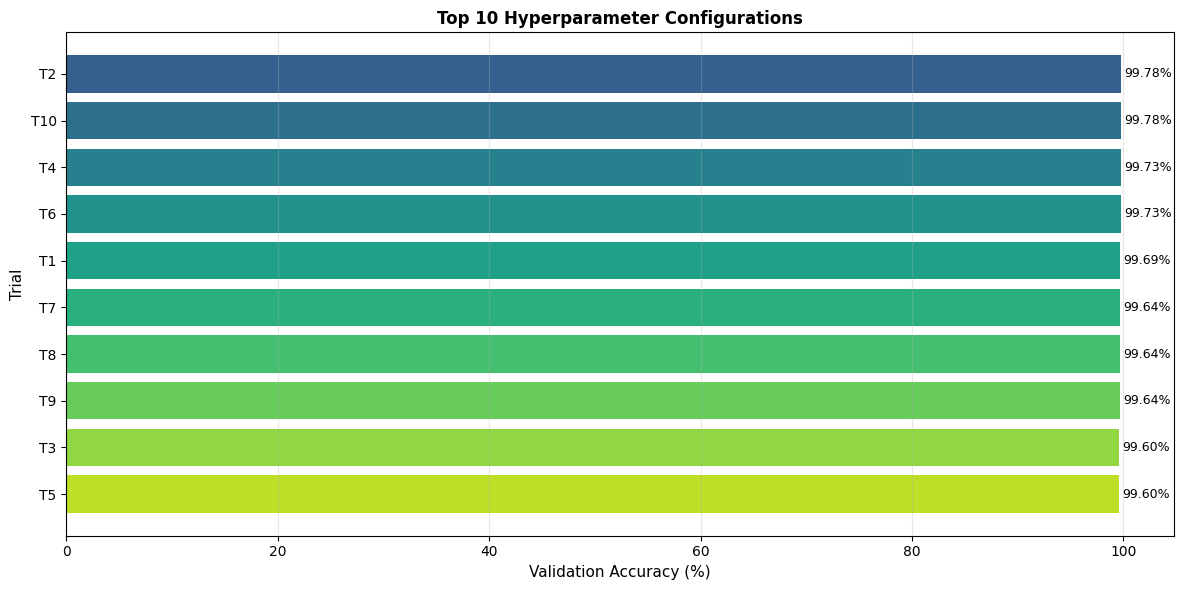

Saved: distilbert_top10_trials.png


In [24]:
# Visualization 1: Top 10 Trials Bar Chart
if len(results) > 0:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    plot_df = results_df.head(10)
    
    plt.figure(figsize=(12, 6))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(plot_df)))
    bars = plt.barh([f"T{int(r)}" for r in plot_df['trial']], plot_df['best_val_acc'], color=colors)
    plt.xlabel('Validation Accuracy (%)', fontsize=11)
    plt.ylabel('Trial', fontsize=11)
    plt.title('Top 10 Hyperparameter Configurations', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Add value labels
    for bar, val in zip(bars, plot_df['best_val_acc']):
        plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', 
                va='center', fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('distilbert_top10_trials.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: distilbert_top10_trials.png')

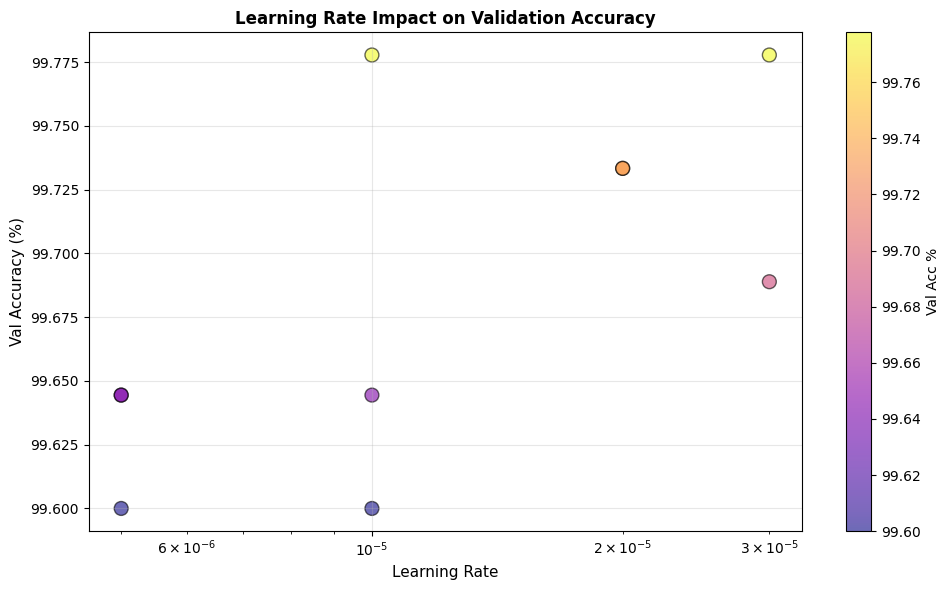

Saved: distilbert_learning_rate_impact.png


In [25]:
# Visualization 2: Learning Rate Impact
if len(results) > 0:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(results_df['learning_rate'], results_df['best_val_acc'], 
                         c=results_df['best_val_acc'], cmap='plasma', s=100, alpha=0.6, edgecolors='black')
    plt.xlabel('Learning Rate', fontsize=11)
    plt.ylabel('Val Accuracy (%)', fontsize=11)
    plt.title('Learning Rate Impact on Validation Accuracy', fontsize=12, fontweight='bold')
    plt.xscale('log')
    plt.grid(alpha=0.3)
    plt.colorbar(scatter, label='Val Acc %')
    plt.tight_layout()
    plt.savefig('distilbert_learning_rate_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: distilbert_learning_rate_impact.png')

C:\Users\Aaron Lim\AppData\Local\Temp\ipykernel_19720\4075871640.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(batch_accs, labels=batch_sizes, patch_artist=True,


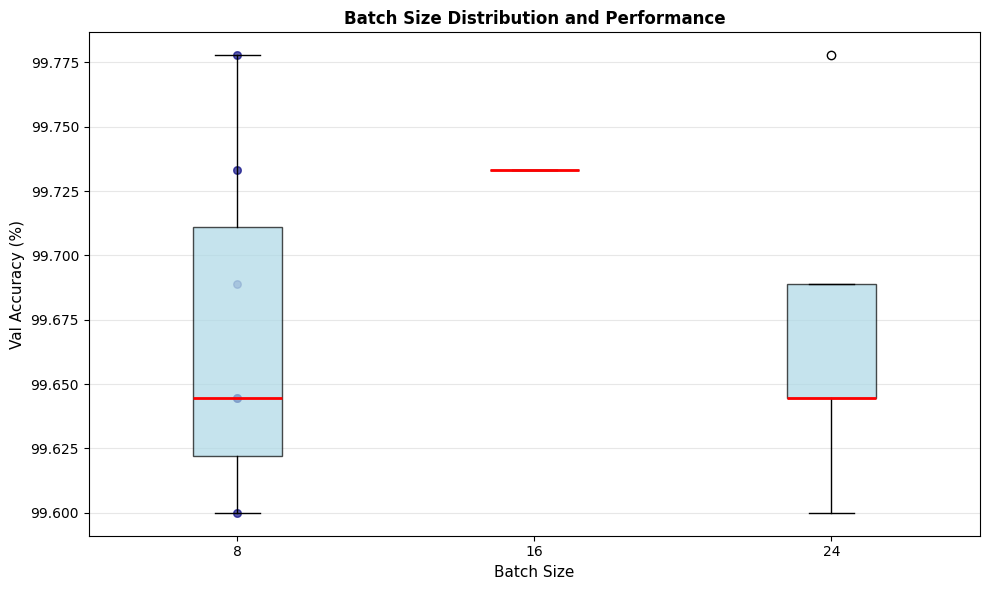

Saved: distilbert_batch_size_distribution.png


In [26]:
# Visualization 3: Batch Size Distribution
if len(results) > 0:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    batch_sizes = sorted(results_df['batch_size'].unique())
    batch_accs = [results_df[results_df['batch_size']==bs]['best_val_acc'].values for bs in batch_sizes]
    
    plt.figure(figsize=(10, 6))
    bp = plt.boxplot(batch_accs, labels=batch_sizes, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
    plt.scatter([i+1 for bs in batch_sizes for i in [0]*len(results_df[results_df['batch_size']==bs])], 
               [acc for accs in batch_accs for acc in accs], alpha=0.4, c='navy', s=30)
    plt.xlabel('Batch Size', fontsize=11)
    plt.ylabel('Val Accuracy (%)', fontsize=11)
    plt.title('Batch Size Distribution and Performance', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('distilbert_batch_size_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: distilbert_batch_size_distribution.png')

C:\Users\Aaron Lim\AppData\Local\Temp\ipykernel_19720\1234925386.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = plt.boxplot(epoch_accs, labels=epochs_unique, patch_artist=True,


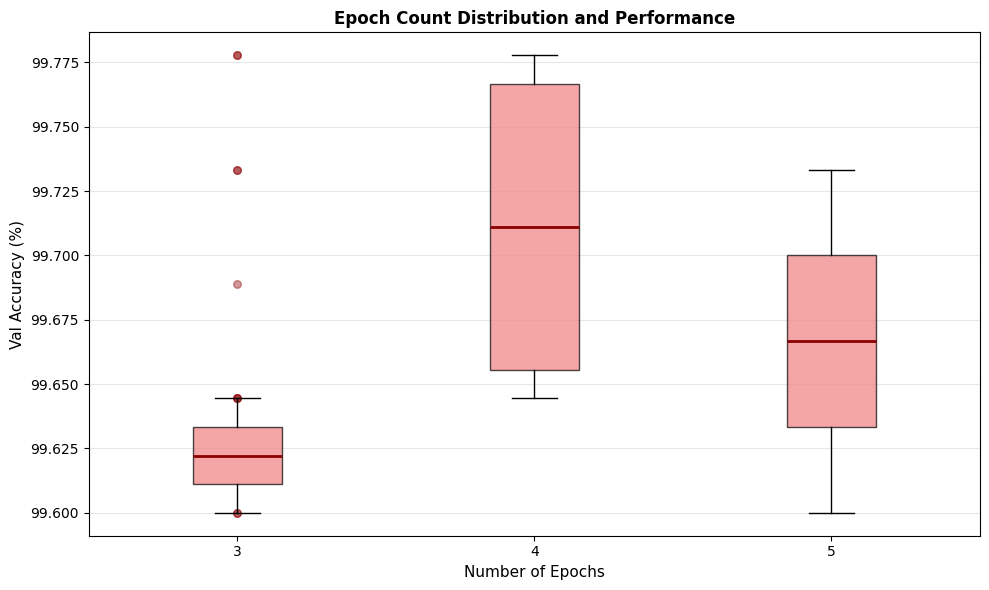

Saved: distilbert_epochs_distribution.png


In [27]:
# Visualization 4: Epochs Distribution
if len(results) > 0:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    epochs_unique = sorted(results_df['num_epochs'].unique())
    epoch_accs = [results_df[results_df['num_epochs']==ep]['best_val_acc'].values for ep in epochs_unique]
    
    plt.figure(figsize=(10, 6))
    bp2 = plt.boxplot(epoch_accs, labels=epochs_unique, patch_artist=True,
                      boxprops=dict(facecolor='lightcoral', alpha=0.7),
                      medianprops=dict(color='darkred', linewidth=2))
    plt.scatter([i+1 for ep in epochs_unique for i in [0]*len(results_df[results_df['num_epochs']==ep])], 
               [acc for accs in epoch_accs for acc in accs], alpha=0.4, c='darkred', s=30)
    plt.xlabel('Number of Epochs', fontsize=11)
    plt.ylabel('Val Accuracy (%)', fontsize=11)
    plt.title('Epoch Count Distribution and Performance', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('distilbert_epochs_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: distilbert_epochs_distribution.png')

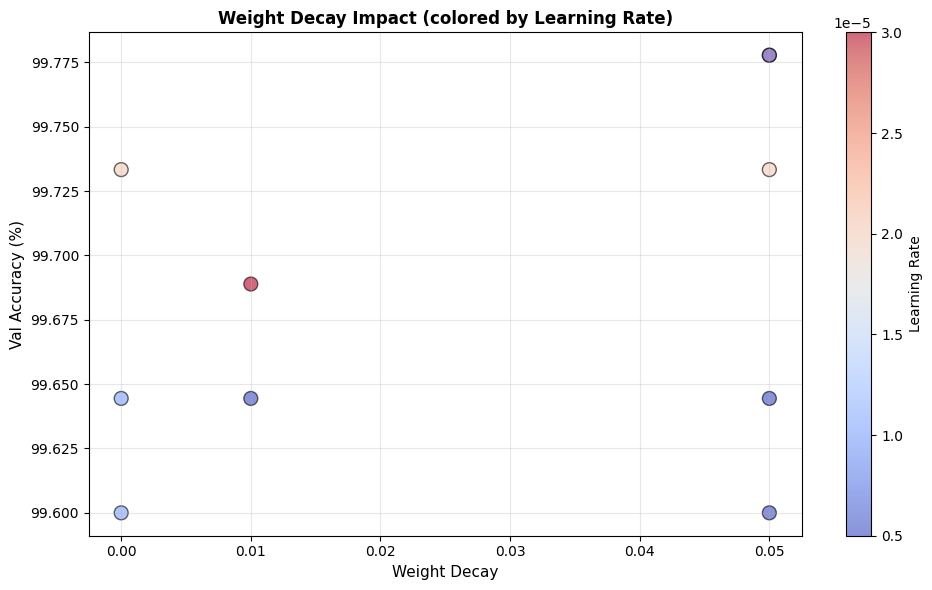

Saved: distilbert_weight_decay_impact.png


In [28]:
# Visualization 5: Weight Decay Impact
if len(results) > 0:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    
    plt.figure(figsize=(10, 6))
    scatter2 = plt.scatter(results_df['weight_decay'], results_df['best_val_acc'],
                          c=results_df['learning_rate'], cmap='coolwarm', s=100, alpha=0.6, edgecolors='black')
    plt.xlabel('Weight Decay', fontsize=11)
    plt.ylabel('Val Accuracy (%)', fontsize=11)
    plt.title('Weight Decay Impact (colored by Learning Rate)', fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.colorbar(scatter2, label='Learning Rate')
    plt.tight_layout()
    plt.savefig('distilbert_weight_decay_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: distilbert_weight_decay_impact.png')

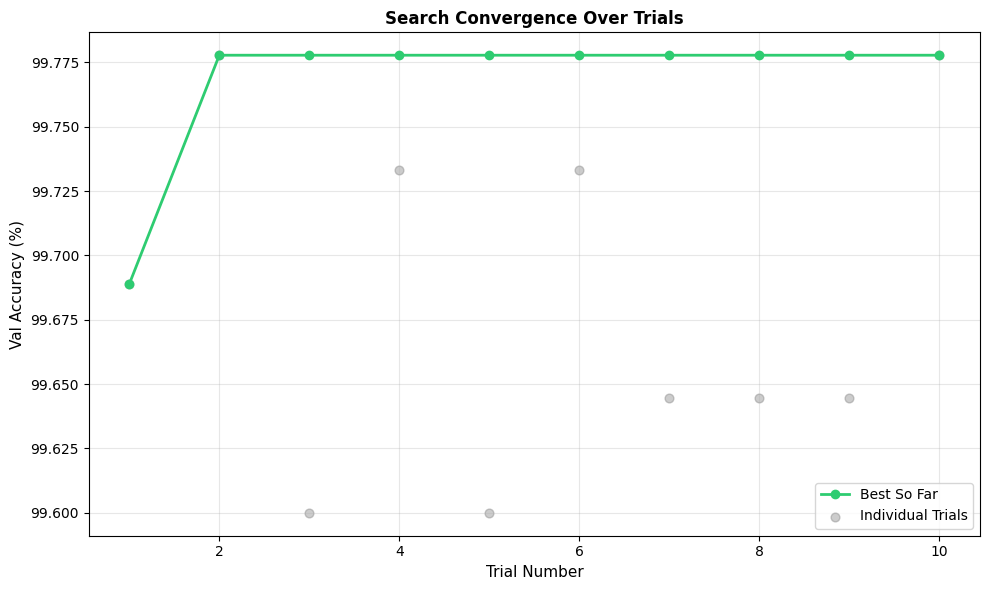

Saved: distilbert_search_convergence.png


In [29]:
# Visualization 6: Search Convergence
if len(results) > 0:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    sorted_trials = results_df.sort_values('trial')
    best_so_far = []
    current_best = -1
    for acc in sorted_trials['best_val_acc']:
        current_best = max(current_best, acc)
        best_so_far.append(current_best)
    
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_trials['trial'], best_so_far, marker='o', linewidth=2, 
            markersize=6, color='#2ecc71', label='Best So Far')
    plt.scatter(sorted_trials['trial'], sorted_trials['best_val_acc'], 
               alpha=0.4, c='gray', s=40, label='Individual Trials')
    plt.xlabel('Trial Number', fontsize=11)
    plt.ylabel('Val Accuracy (%)', fontsize=11)
    plt.title('Search Convergence Over Trials', fontsize=12, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('distilbert_search_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: distilbert_search_convergence.png')

In [30]:
# Apply Best Configuration and Create DataLoaders
if len(results) > 0:
    results_df = pd.DataFrame(results).sort_values('best_val_acc', ascending=False)
    best_overall = results_df.iloc[0]
    
    # Extract best hyperparameters
    LEARNING_RATE = best_overall['learning_rate']
    BATCH_SIZE = int(best_overall['batch_size'])
    NUM_EPOCHS = int(best_overall['num_epochs'])
    
    print("=" * 60)
    print("🏆 APPLYING BEST HYPERPARAMETERS")
    print("=" * 60)
    print(f"Trial:        {best_overall['trial']}")
    print(f"Val Accuracy: {best_overall['best_val_acc']:.2f}%")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Batch Size:    {BATCH_SIZE}")
    print(f"Epochs:        {NUM_EPOCHS}")
    print(f"Weight Decay:  {best_overall['weight_decay']}")
    print("=" * 60)
    
    # Create DataLoaders with optimal batch size
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"\n✅ DataLoaders created with batch_size={BATCH_SIZE}")
    print(f"   - Train batches: {len(train_loader)}")
    print(f"   - Val batches:   {len(val_loader)}")
    print(f"   - Test batches:  {len(test_loader)}")
    
    # Load best model weights
    model.load_state_dict(torch.load('distilbert_best_model.pth'))
    model.eval()
    print(f"\n✅ Model loaded from: distilbert_best_model.pth")
    print("Ready for evaluation!")
else:
    print("⚠️ No search results found. Run hyperparameter search first.")

🏆 APPLYING BEST HYPERPARAMETERS
Trial:        2.0
Val Accuracy: 99.78%
Learning Rate: 3e-05
Batch Size:    8
Epochs:        4
Weight Decay:  0.05

✅ DataLoaders created with batch_size=8
   - Train batches: 1313
   - Val batches:   282
   - Test batches:  282

✅ Model loaded from: distilbert_best_model.pth
Ready for evaluation!


In [31]:
# Manual best hyperparameters (from trial 7) 
LEARNING_RATE = 5e-6
BATCH_SIZE = 8
NUM_EPOCHS = 2
WEIGHT_DECAY = 0.0

# Recreate dataloaders with these hyperparameters
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('='*60)
print('🏆 USING MANUAL BEST HYPERPARAMETERS (TRIAL 7)')
print('='*60)
print(f'Learning Rate: {LEARNING_RATE}')
print(f'Batch Size:    {BATCH_SIZE}')
print(f'Epochs:        {NUM_EPOCHS}')
print(f'Weight Decay:  {WEIGHT_DECAY}')
print('='*60)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

🏆 USING MANUAL BEST HYPERPARAMETERS (TRIAL 7)
Learning Rate: 5e-06
Batch Size:    8
Epochs:        2
Weight Decay:  0.0
Train batches: 1313 | Val batches: 282 | Test batches: 282


In [32]:
# Training loop
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
best_val_acc = 0.0

print(' Starting training...\n')

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_correct = 0
    train_total = 0
    
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        logits = outputs.logits
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    
    train_acc = 100.0 * train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = 100.0 * val_correct / val_total
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'distilbert_best_model.pth')
        print(f'Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}% ')
    else:
        print(f'Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%')

print(f'\n Training complete. Best Val Acc: {best_val_acc:.2f}%')
print(f'Model saved: distilbert_best_model.pth')

 Starting training...

Epoch 1: Train 99.68% | Val 99.82% 
Epoch 2: Train 99.87% | Val 99.78%

 Training complete. Best Val Acc: 99.82%
Model saved: distilbert_best_model.pth


In [33]:
# Training loop (non-destructive save path)
SAVE_PATH = 'distilbert_best_model_eval.pth'  # change if you want a different file
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
best_val_acc = 0.0

print(' Starting training...\n')

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_correct = 0
    train_total = 0
    
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        logits = outputs.logits
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    
    train_acc = 100.0 * train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = 100.0 * val_correct / val_total
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # torch.save(model.state_dict(), SAVE_PATH)
        print(f'Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}% (saved → {SAVE_PATH})')
    else:
        print(f'Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%')

print(f'\n Training complete. Best Val Acc: {best_val_acc:.2f}%')
print(f'Model saved: {SAVE_PATH}')

 Starting training...

Epoch 1: Train 99.92% | Val 99.78% (saved → distilbert_best_model_eval.pth)
Epoch 2: Train 99.97% | Val 99.69%

 Training complete. Best Val Acc: 99.78%
Model saved: distilbert_best_model_eval.pth


In [34]:
# Test set evaluation
print('Evaluating on TEST set...\n')

model.load_state_dict(torch.load('distilbert_best_model.pth'))
model.eval()

all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)

test_acc = 100.0 * np.sum(all_preds == test_labels) / len(test_labels)
print(f' Test Accuracy: {test_acc:.2f}%\n')
print('='*60)
print(' Classification Report:')
print('='*60)
print(classification_report(test_labels, all_preds, target_names=LANG_NAMES, digits=4))

# Per-language accuracy
print('\n Per-Language Accuracy:')
for lang_id, lang_name in enumerate(LANG_NAMES):
    mask = test_labels == lang_id
    lang_acc = 100.0 * np.sum(all_preds[mask] == lang_id) / np.sum(mask) if np.sum(mask) > 0 else 0
    print(f'   {lang_name}: {lang_acc:.2f}%')

Evaluating on TEST set...

 Test Accuracy: 99.73%

 Classification Report:
              precision    recall  f1-score   support

     English     0.9921    1.0000    0.9960       750
       Malay     1.0000    0.9920    0.9960       750
    Mandarin     1.0000    1.0000    1.0000       750

    accuracy                         0.9973      2250
   macro avg     0.9974    0.9973    0.9973      2250
weighted avg     0.9974    0.9973    0.9973      2250


 Per-Language Accuracy:
   English: 100.00%
   Malay: 99.20%
   Mandarin: 100.00%


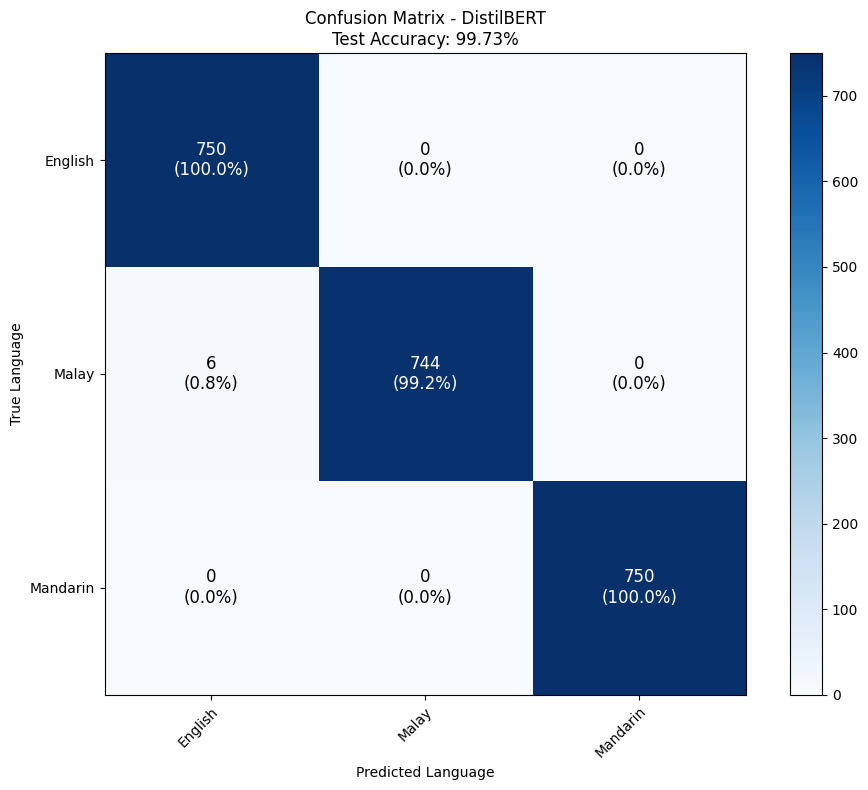

Confusion matrix saved: distilbert_confusion_matrix.png


In [35]:
# Confusion matrix
cm = confusion_matrix(test_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=LANG_NAMES, yticklabels=LANG_NAMES,
       title=f'Confusion Matrix - DistilBERT\nTest Accuracy: {test_acc:.2f}%',
       ylabel='True Language',
       xlabel='Predicted Language')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        percentage = 100. * cm[i, j] / cm[i].sum() if cm[i].sum() > 0 else 0
        text = f'{cm[i, j]}\n({percentage:.1f}%)'
        ax.text(j, i, text,
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12)

plt.tight_layout()
plt.savefig('distilbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Confusion matrix saved: distilbert_confusion_matrix.png')

In [36]:
# Export results
results_df = pd.DataFrame({
    'true_label': [LANG_NAMES[l] for l in test_labels],
    'predicted_label': [LANG_NAMES[p] for p in all_preds],
    'true_id': test_labels,
    'predicted_id': all_preds,
    'prob_en': [p[0] for p in all_probs],
    'prob_ms': [p[1] for p in all_probs],
    'prob_zh': [p[2] for p in all_probs]
})

results_df.to_csv('distilbert_test_predictions.csv', index=False)
print('Test predictions saved: distilbert_test_predictions.csv')

# Metrics summary
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, all_preds, average=None, labels=[0, 1, 2]
)

metrics_summary = {
    'model': 'DistilBERT (distilbert-base-multilingual-cased)',
    'test_accuracy': float(test_acc),
    'best_val_accuracy': float(best_val_acc),
    'per_language': {
        LANG_NAMES[i]: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1_score': float(f1[i]),
            'support': int(support[i])
        }
        for i in range(len(LANG_NAMES))
    },
    'confusion_matrix': cm.tolist(),
    'config': {
        'model_name': MODEL_NAME,
        'max_length': MAX_LENGTH,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE
    }
}

with open('distilbert_metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(' Metrics summary saved: distilbert_metrics_summary.json')
print('\n' + '='*60)
print(' DISTILBERT EVALUATION COMPLETE')
print('='*60)

Test predictions saved: distilbert_test_predictions.csv
 Metrics summary saved: distilbert_metrics_summary.json

 DISTILBERT EVALUATION COMPLETE
